In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import TimeSeriesSplit

In [5]:
merged_dataset = pd.read_parquet("../../data/final_merged_dataset.parquet")

In [6]:
merged_dataset.shape

(853536, 465)

In [7]:
pd.set_option("display.max_columns", None)

In [8]:
y = merged_dataset["alarm_active"]

X = merged_dataset.drop(
    columns=[
        "alarm_active",
        "day_sunset",
        "day_sunrise",
        "datetime_hour"
    ],
    errors="ignore"
)

In [9]:
X = X.select_dtypes(include=["number", "bool"]).copy()

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype("int8")

In [10]:
alarm_related = [col for col in X.columns if "alarm" in col.lower() or "lag" in col.lower()]
print(alarm_related)

['alarm_minutes_in_hour', 'alarm_lag_1', 'alarm_lag_3', 'alarm_lag_6', 'alarm_lag_12', 'alarms_in_last_24h', 'total_active_alarms_lag1', 'neighbour_alarms', 'hours_since_last_alarm']


In [11]:
leak_cols = [
    "hours_since_last_alarm",
    "alarm_lag_1",
    "alarms_in_last_24h",
    'alarm_minutes_in_hour',
    'neighbour_alarms'
]
X = X.drop(columns=leak_cols, errors="ignore")

In [12]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [13]:
print(X_train.isna().sum().sort_values(ascending=False).head(20))

day_tempmax        0
day_tempmin        0
day_temp           0
day_dew            0
day_humidity       0
day_precip         0
day_precipcover    0
day_snow           0
day_windgust       0
day_cloudcover     0
day_moonphase      0
hour_temp          0
hour_feelslike     0
hour_humidity      0
hour_dew           0
hour_precip        0
hour_snow          0
hour_snowdepth     0
hour_windgust      0
hour_windspeed     0
dtype: int64


In [14]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

train_medians = X_train.median()

X_train_imp = X_train.fillna(train_medians)
X_test_imp = X_test.fillna(train_medians)

In [15]:
tscv = TimeSeriesSplit(n_splits=3)

param_grid = [
    {"n_estimators": 50, "max_depth": 8},
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": 10}
]

best_score = -np.inf
best_params = None

In [16]:
for params in param_grid:
    scores = []

    for train_idx, val_idx in tscv.split(X_train_imp):
        X_tr = X_train_imp.iloc[train_idx]
        X_val = X_train_imp.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = RandomForestClassifier(
            **params,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_tr, y_tr)
        y_val_proba = model.predict_proba(X_val)[:, 1]

        score = roc_auc_score(y_val, y_val_proba)
        scores.append(score)

    mean_score = np.mean(scores)
    print(f"{params} -> ROC-AUC: {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

print("Best params:", best_params)

{'n_estimators': 50, 'max_depth': 8} -> ROC-AUC: 0.7967
{'n_estimators': 100, 'max_depth': 10} -> ROC-AUC: 0.8204
{'n_estimators': 200, 'max_depth': 10} -> ROC-AUC: 0.8204
Best params: {'n_estimators': 200, 'max_depth': 10}


In [17]:
rf_model = RandomForestClassifier(
    **best_params,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,

    n_jobs=-1
)

rf_model.fit(X_train_imp, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [18]:
y_pred = rf_model.predict(X_test_imp)
y_proba = rf_model.predict_proba(X_test_imp)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.95      0.81      0.87    144777
           1       0.41      0.75      0.53     25931

    accuracy                           0.80    170708
   macro avg       0.68      0.78      0.70    170708
weighted avg       0.87      0.80      0.82    170708

ROC-AUC: 0.856679921103249
PR-AUC: 0.615999534679619


In [19]:
threshold = 0.4
y_pred_custom = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.97      0.55      0.70    144777
           1       0.26      0.90      0.41     25931

    accuracy                           0.60    170708
   macro avg       0.62      0.72      0.55    170708
weighted avg       0.86      0.60      0.66    170708



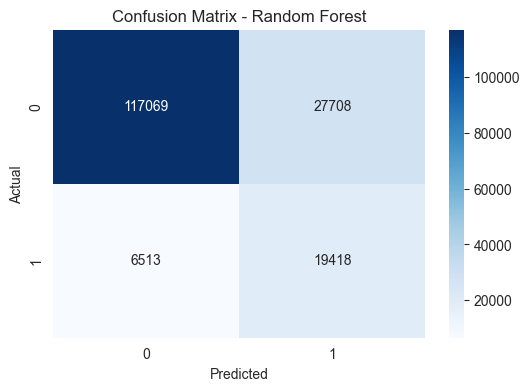

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

print(top20)

alarm_lag_3                 0.157598
total_active_alarms_lag1    0.116789
alarm_lag_6                 0.110309
alarm_lag_12                0.094242
region_id                   0.038064
tg_topic_2                  0.024189
tg_topic_0                  0.021626
tg_topic_8                  0.021540
tg_topic_5                  0.016354
tg_topic_std                0.015703
isw_topic_1                 0.013587
tg_topic_9                  0.011929
tg_topic_4                  0.011097
tg_topic_3                  0.009226
isw_topic_max               0.008887
isw_topic_0                 0.008236
tg_topic_1                  0.008012
tg_topic_max                0.007565
tg_topic_7                  0.007383
tg_topic_entropy            0.007379
dtype: float64


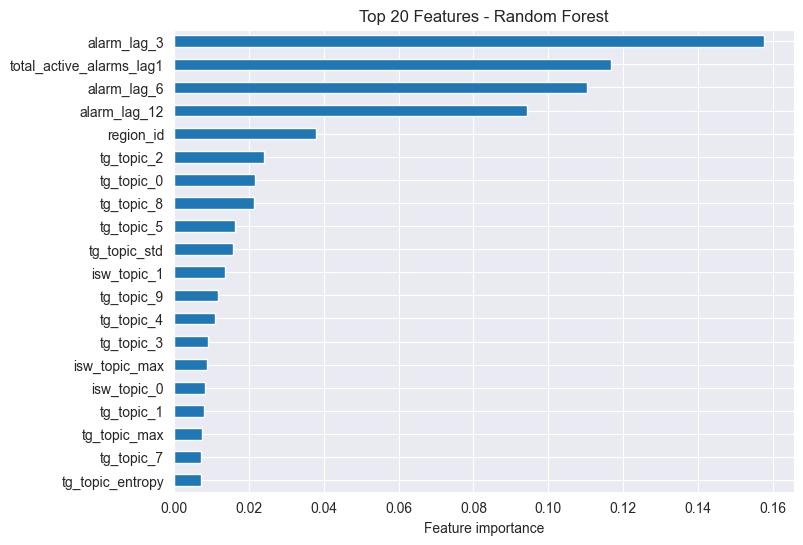

In [22]:
top20.sort_values().plot(kind="barh", figsize=(8, 6))
plt.title("Top 20 Features - Random Forest")
plt.xlabel("Feature importance")
plt.show()